In [1]:
import pandas as pd

# Load dataset
xlsx = pd.ExcelFile('nationaldatabaseofchildcareprices.xlsx')
print("Available sheets:", xlsx.sheet_names)

# Load first sheet (update sheet name if needed)
df = xlsx.parse(xlsx.sheet_names[0])

# Print all column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check for missing values in each column
print("\nMissing Values per Column:")
print(df.isnull().sum())
# Set numeric threshold
missing_value_threshold = 20  # You can change this number as needed
print("Missing values in 'MCBto5':", df['MCBto5'].isnull().sum())


# Drop columns that exceed the threshold
df_cleaned = df.dropna(axis=1, thresh=(len(df) - missing_value_threshold))

# Print remaining columns
print(f"\nRemaining columns after dropping those with more than {missing_value_threshold} missing values:")
print(df_cleaned.columns.tolist())

# overwrite the original DataFrame
df = df_cleaned



Available sheets: ['nationaldatabaseofchildcare']

Column Names:
['State_Name', 'State_Abbreviation', 'County_Name', 'County_FIPS_Code', 'StudyYear', 'UNR_16', 'FUNR_16', 'MUNR_16', 'UNR_20to64', 'FUNR_20to64', 'MUNR_20to64', 'FLFPR_20to64', 'FLFPR_20to64_Under6', 'FLFPR_20to64_6to17', 'FLFPR_20to64_Under6_6to17', 'MLFPR_20to64', 'PR_F', 'PR_P', 'MHI', 'ME', 'FME', 'MME', 'MHI_2018', 'ME_2018', 'FME_2018', 'MME_2018', 'TotalPop', 'OneRace', 'OneRace_W', 'OneRace_B', 'OneRace_I', 'OneRace_A', 'OneRace_H', 'OneRace_Other', 'TwoRaces', 'Hispanic', 'Households', 'H_Under6_BothWork', 'H_Under6_FWork', 'H_Under6_MWork', 'H_Under6_SingleM', 'H_6to17_BothWork', 'H_6to17_Fwork', 'H_6to17_Mwork', 'H_6to17_SingleM', 'EMP_M', 'MEMP_M', 'FEMP_M', 'EMP_Service', 'MEMP_Service', 'FEMP_Service', 'EMP_Sales', 'MEMP_Sales', 'FEMP_Sales', 'EMP_N', 'MEMP_N', 'FEMP_N', 'EMP_P', 'MEMP_P', 'FEMP_P', 'iUNR_16', 'iFUNR_16', 'iMUNR_16', 'iUNR_20to64', 'iFUNR_20to64', 'iMUNR_20to64', 'iFLFPR_20to64', 'iFLFPR_20t

In [2]:
# Drop rows with missing values in key columns
df = df[['StudyYear', 'State_Name', 'ME', 'MHI', 'H_Under6_BothWork']].dropna()

# --------------------------------------
# 1. Childcare Cost-to-Income Ratio Over Time (using ME)
# --------------------------------------
df['CostToIncome'] = df['ME'] / df['MHI']

ratio_by_year = df.groupby('StudyYear')['CostToIncome'].mean()
print("1. Average Childcare Cost-to-Income Ratio by Year (using ME):")
print(ratio_by_year)
print("\n")

# --------------------------------------
# 2. Childcare Costs by Working Parent Households
# --------------------------------------
median_bothwork = df['H_Under6_BothWork'].median()

high_demand = df[df['H_Under6_BothWork'] >= median_bothwork]
low_demand = df[df['H_Under6_BothWork'] < median_bothwork]

avg_cost_high = high_demand['ME'].mean()
avg_cost_low = low_demand['ME'].mean()

print("2. Average Childcare Cost in High-Demand Areas (Both Parents Work):", round(avg_cost_high, 2))
print("   Average Childcare Cost in Low-Demand Areas:", round(avg_cost_low, 2))
print("\n")

# --------------------------------------
# 3. States with Highest Childcare Burden (ME / MHI)
# --------------------------------------
burden_by_state = df.groupby('State_Name')[['ME', 'MHI']].mean()
burden_by_state['CostToIncome'] = burden_by_state['ME'] / burden_by_state['MHI']
burden_by_state = burden_by_state.sort_values('CostToIncome', ascending=False)

print("3. Top 5 States with Highest Childcare Burden (ME / MHI):")
print(burden_by_state[['CostToIncome']].head(5))

1. Average Childcare Cost-to-Income Ratio by Year (using ME):
StudyYear
2008    0.587535
2009    0.589398
2010    0.594920
2011    0.593981
2012    0.597198
2013    0.598639
2014    0.601090
2015    0.604471
2016    0.602979
2017    0.603411
2018    0.603813
Name: CostToIncome, dtype: float64


2. Average Childcare Cost in High-Demand Areas (Both Parents Work): 28574.63
   Average Childcare Cost in Low-Demand Areas: 25574.87


3. Top 5 States with Highest Childcare Burden (ME / MHI):
                      CostToIncome
State_Name                        
Mississippi               0.693234
District of Columbia      0.678126
Alabama                   0.666728
West Virginia             0.662299
Arkansas                  0.651296


In [3]:
print("Columns in df:")
print(df.columns.tolist())

Columns in df:
['StudyYear', 'State_Name', 'ME', 'MHI', 'H_Under6_BothWork', 'CostToIncome']


In [4]:
df.to_csv('childcare_burden_clean.csv', index=False)
print("File saved as childcare_burden_clean.csv")

File saved as childcare_burden_clean.csv


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


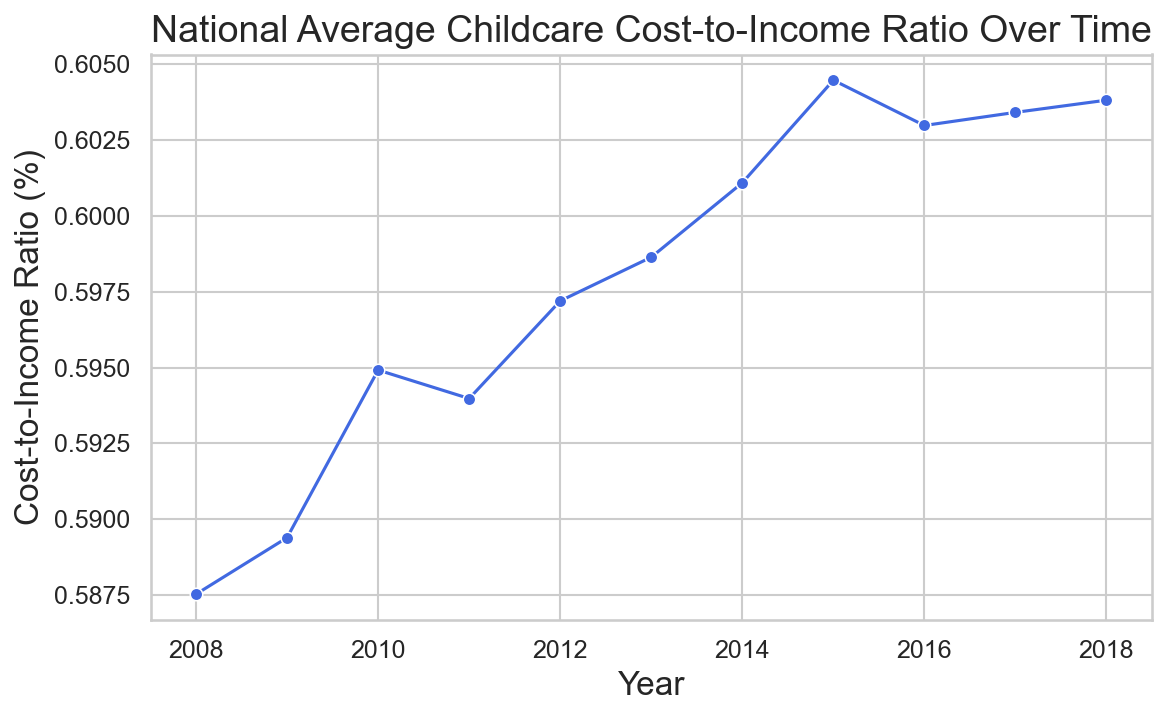

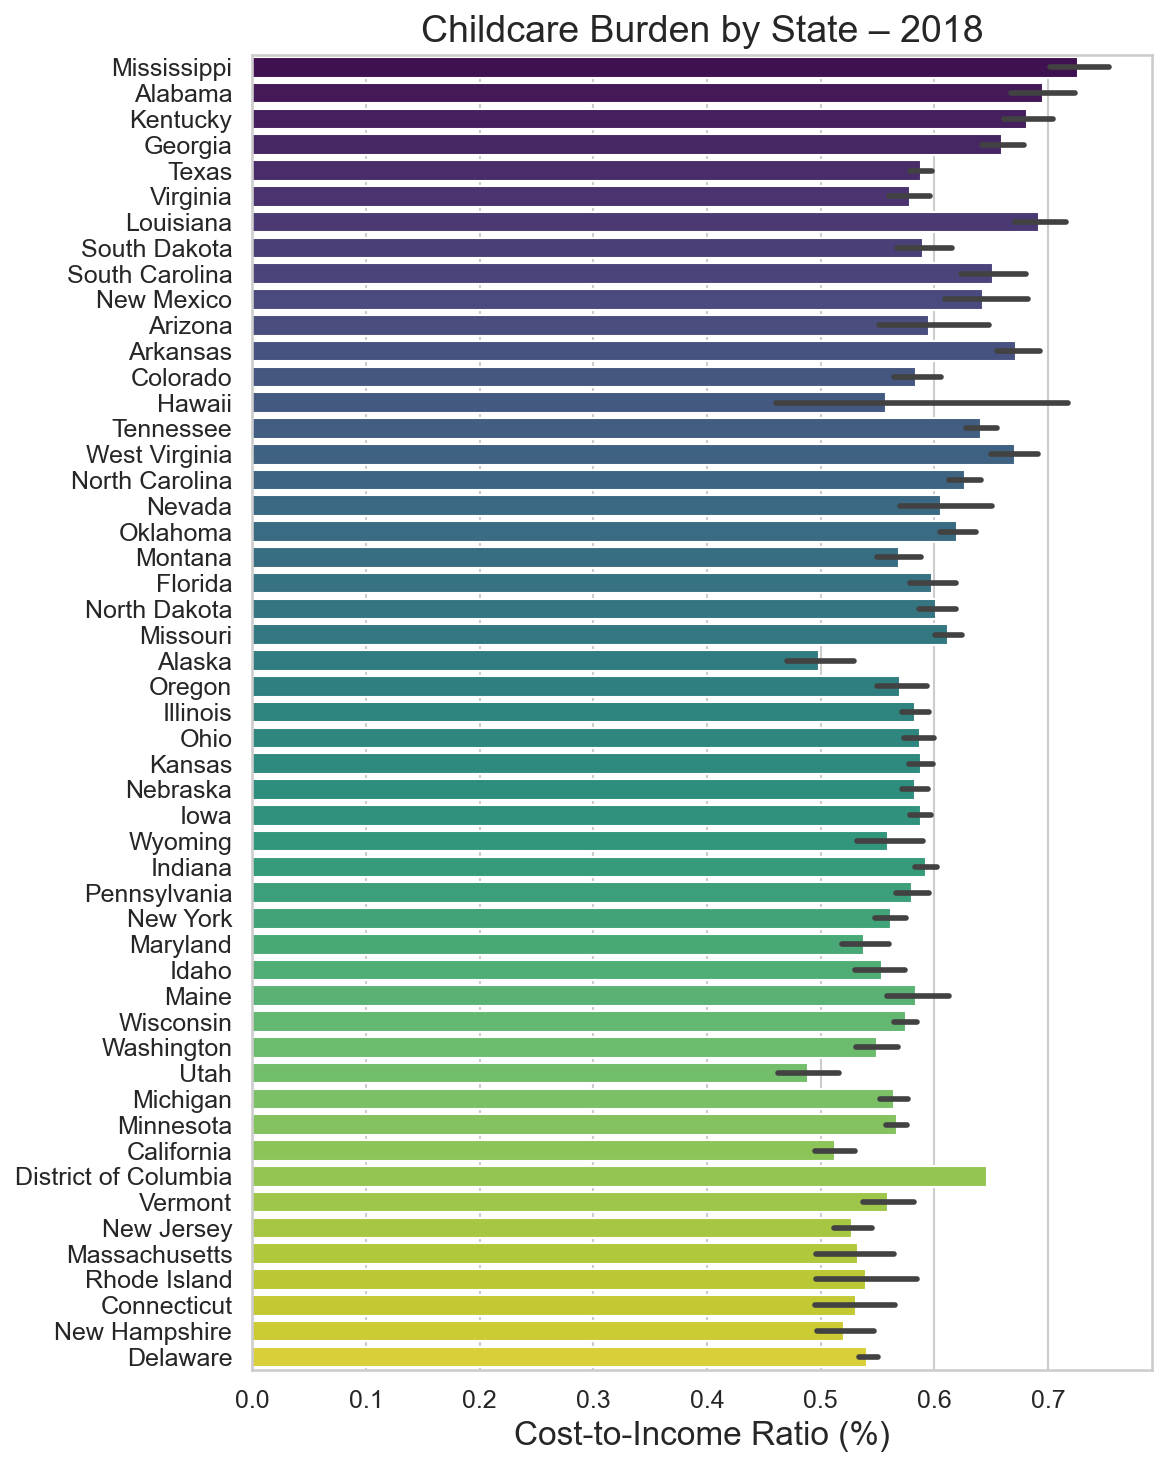

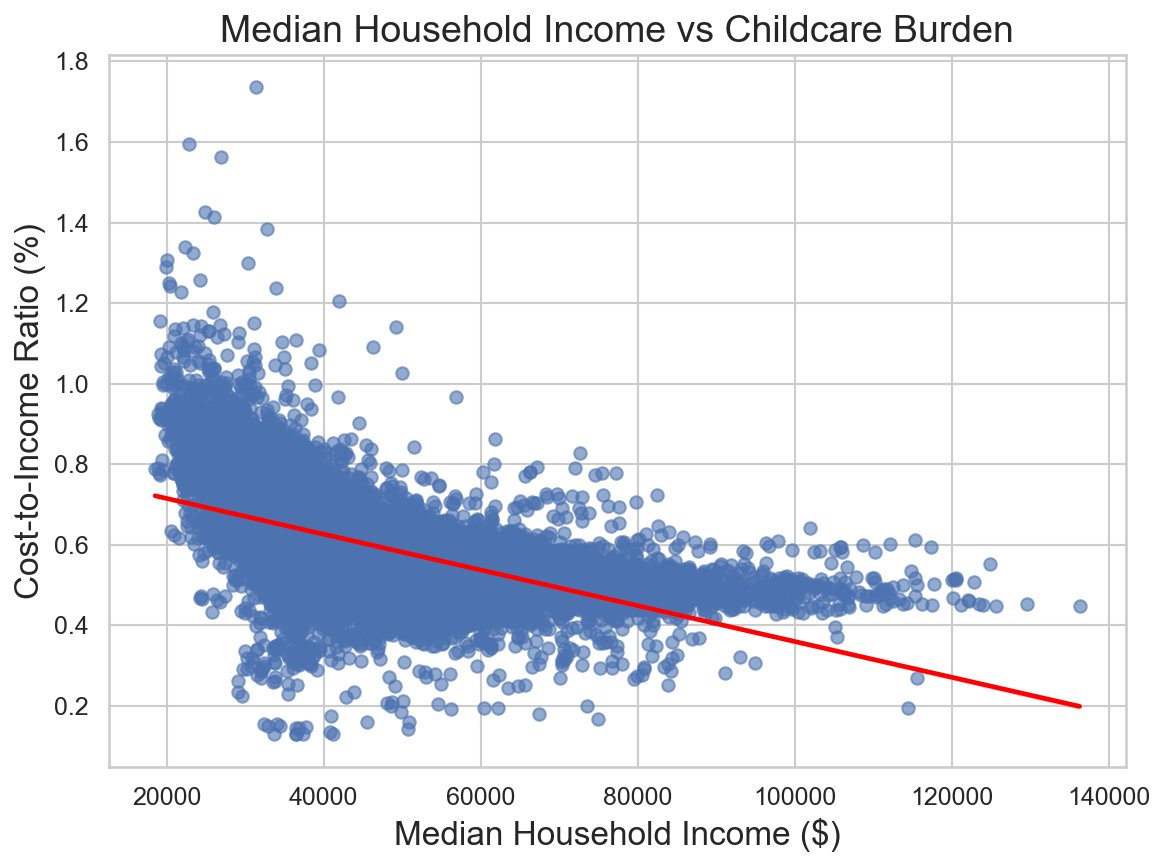

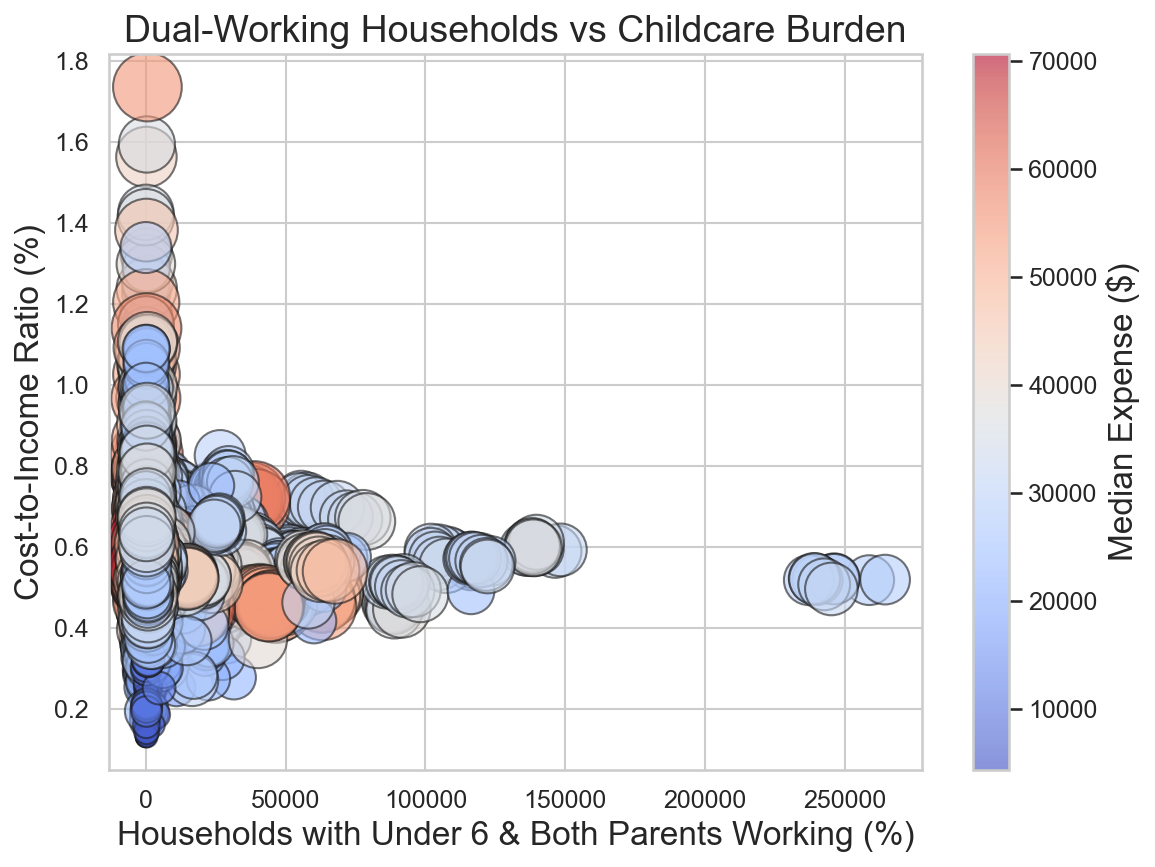

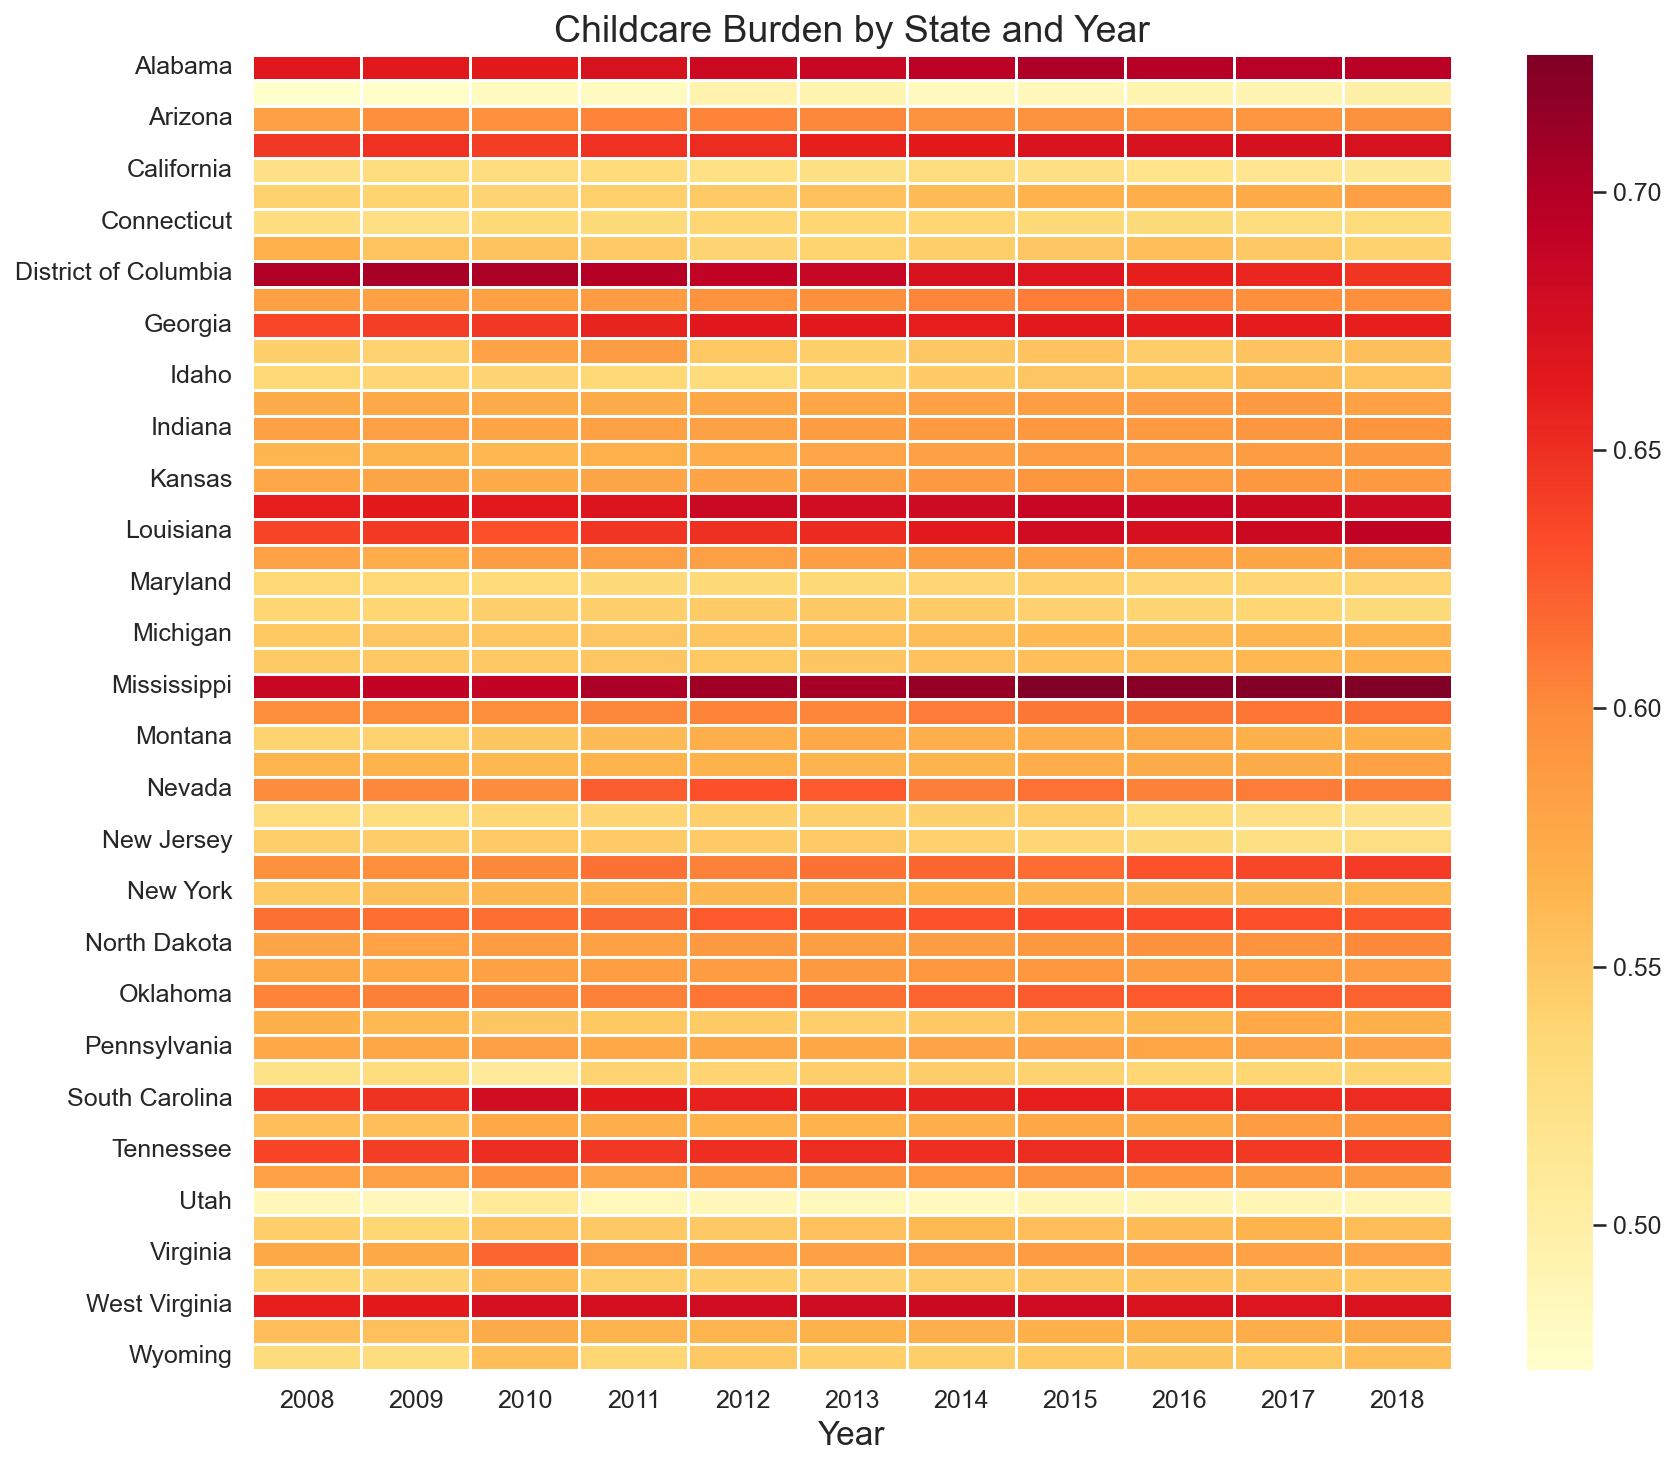

✅ All charts saved in 'figures' folder and displayed above.


In [6]:
# ==== SETTINGS ====
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 14,       # Bigger font for PowerPoint
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.dpi': 150
})

# Create output folder
os.makedirs("figures", exist_ok=True)

# ==== 1. Trend Over Time – National Average Cost-to-Income Ratio ====
avg_trend = df.groupby('StudyYear', as_index=False)['CostToIncome'].mean()

fig, ax = plt.subplots(figsize=(8,5))
sns.lineplot(data=avg_trend, x='StudyYear', y='CostToIncome', marker='o', ax=ax, color='royalblue')
ax.set_title("National Average Childcare Cost-to-Income Ratio Over Time")
ax.set_ylabel("Cost-to-Income Ratio (%)")
ax.set_xlabel("Year")
plt.tight_layout()
plt.savefig("figures/trend_cost_to_income.png", bbox_inches="tight")
plt.show()

# ==== 2. State Comparisons – Latest Year ====
latest_year = df['StudyYear'].max()
state_burden = df[df['StudyYear'] == latest_year].sort_values('CostToIncome', ascending=False)

fig, ax = plt.subplots(figsize=(8,10))
sns.barplot(data=state_burden, y='State_Name', x='CostToIncome', palette='viridis')
ax.set_title(f"Childcare Burden by State – {latest_year}")
ax.set_xlabel("Cost-to-Income Ratio (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/state_comparison.png", bbox_inches="tight")
plt.show()

# ==== 3. Scatter – Median Household Income vs Burden ====
fig, ax = plt.subplots(figsize=(8,6))
sns.regplot(data=df, x='MHI', y='CostToIncome', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
ax.set_title("Median Household Income vs Childcare Burden")
ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Cost-to-Income Ratio (%)")
plt.tight_layout()
plt.savefig("figures/income_vs_burden.png", bbox_inches="tight")
plt.show()

# ==== 4. Bubble – Dual-Working Households vs Burden ====
fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(df['H_Under6_BothWork'], df['CostToIncome'],
                     s=df['ME']/50, alpha=0.6, c=df['ME'], cmap='coolwarm', edgecolors='k')
ax.set_title("Dual-Working Households vs Childcare Burden")
ax.set_xlabel("Households with Under 6 & Both Parents Working (%)")
ax.set_ylabel("Cost-to-Income Ratio (%)")
cbar = plt.colorbar(scatter)
cbar.set_label("Median Expense ($)")
plt.tight_layout()
plt.savefig("figures/dual_working_vs_burden.png", bbox_inches="tight")
plt.show()

# ==== 5. Heatmap – State and Year ====
heat_df = df.pivot_table(index='State_Name', columns='StudyYear', values='CostToIncome')
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(heat_df, cmap='YlOrRd', annot=False, linewidths=0.5)
ax.set_title("Childcare Burden by State and Year")
ax.set_xlabel("Year")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/heatmap_state_year.png", bbox_inches="tight")
plt.show()

print("✅ All charts saved in 'figures' folder and displayed above.")